In [7]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

c:\Users\mkcak\anaconda3\envs\financetech\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\mkcak\anaconda3\envs\financetech\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\mkcak\anaconda3\envs\financetech\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update

In [8]:
from pathlib import Path
import joblib

# === Directories for LSTM models and results ===
BASE_DIR = Path("../")  # adjust if needed

LSTM_MODELS_DIR = BASE_DIR / "models" / "lstm"
LSTM_RESULTS_DIR = BASE_DIR / "results" / "lstm"

LSTM_MODELS_DIR.mkdir(parents=True, exist_ok=True)
LSTM_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("LSTM models dir :", LSTM_MODELS_DIR)
print("LSTM results dir:", LSTM_RESULTS_DIR)


LSTM models dir : ..\models\lstm
LSTM results dir: ..\results\lstm


In [9]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [10]:

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Data + Feature Setup

In [11]:
features = pd.read_parquet("../../data/processed/market_all_features_with_sentiment.parquet")

print("Raw shape:", features.shape)
features.head()


Raw shape: (52424, 34)


,date,open,high,low,close,volume,adj close,ticker,sector,cap,return,log_return,year,vol21,vol63,ret_ema21,ret_ema63,px_ma21,px_ma63,px_ma200,trend200_up,sent_mean,sent_std,sent_count,sent_pos,sent_neg,sent_neu,sent_daily_cat,sent_lag1,sent_cat_lag1,sent_roll3,row_id,is_train,set
0,2018-01-04,19.838642,19.958017,19.749111,19.935635,5738092.0,19.935635,ABB,Real Estate - Energy - Industrials,Mid Cap,0.010972,0.010913,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,ABB|2018-01-04,True,train
1,2018-01-04,7.882366,7.882366,7.882366,7.882366,0.0,7.882366,ALPINE,Consumer Discretionary,Large Cap,0.000000,0.000000,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,ALPINE|2018-01-04,True,train
2,2018-01-04,332.666046,333.091339,317.440460,323.224487,111998.0,323.224487,ARYZTA,Consumer Staples,Mid Cap,-0.024390,-0.024693,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.946913,0.0,1.0,1.0,0.0,0.0,positive,0.0,None,0.999941,ARYZTA|2018-01-04,True,train
3,2018-01-04,107.037628,107.741360,106.545007,107.670982,111416.0,107.670982,BALOISE,Insurance,Mid Cap,0.009235,0.009192,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,BALOISE|2018-01-04,True,train
4,2018-01-04,47.071196,47.562372,47.071196,47.480511,19374.0,47.480511,BKW ENERGIE,Real Estate - Energy - Industrials,Small Cap,0.003460,0.003454,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.041373,0.0,1.0,0.0,0.0,1.0,neutral,0.0,None,0.995683,BKW ENERGIE|2018-01-04,True,train


In [12]:
# How many news per ticker?
news_counts = (
    features.groupby("ticker")["sent_count"]
            .sum()
            .sort_values(ascending=False)
)

news_counts


ticker
UBS                 30518.0
SWISSCOM             7052.0
NESTLE               5541.0
VONTOBEL             3208.0
BKW ENERGIE          3164.0
ABB                  3140.0
JULIUS BAER          2717.0
HELVETIA             2216.0
LONZA                2065.0
SWATCH               1952.0
SWISS LIFE           1928.0
SWISS RE             1761.0
HOLCIM               1630.0
ZURICH INSURANCE     1319.0
EMMI                 1297.0
RICHEMONT            1264.0
LOGITECH              969.0
BALOISE               895.0
SWISSQUOTE            887.0
ARYZTA                800.0
GIVAUDAN              770.0
LANDIS                770.0
BLKB                  526.0
SWISS PRIME SITE      438.0
ROCHE                 320.0
NOVARTIS              279.0
ALCON                 240.0
SANTHERA               97.0
ALPINE                 73.0
REISHAUER              67.0
Name: sent_count, dtype: float64

### Filter to eligible tickers

In [13]:
# Same threshold and tickers as in XGBoost notebook
THRESHOLD = 1800
eligible_tickers = news_counts[news_counts >= THRESHOLD].index.tolist()

print("Eligible tickers (news-rich):", eligible_tickers)
print("Number of eligible tickers:", len(eligible_tickers))

features = features[features["ticker"].isin(eligible_tickers)].copy()
print("After filtering eligible tickers:", features.shape)
features[["date", "ticker", "sent_count"]]


Eligible tickers (news-rich): ['UBS', 'SWISSCOM', 'NESTLE', 'VONTOBEL', 'BKW ENERGIE', 'ABB', 'JULIUS BAER', 'HELVETIA', 'LONZA', 'SWATCH', 'SWISS LIFE']
Number of eligible tickers: 11
After filtering eligible tickers: (19338, 34)


,date,ticker,sent_count
0,2018-01-04,ABB,0.0
4,2018-01-04,BKW ENERGIE,1.0
8,2018-01-04,HELVETIA,0.0
10,2018-01-04,JULIUS BAER,0.0
13,2018-01-04,LONZA,0.0
...,...,...,...
52415,2024-12-30,SWATCH,2.0
52416,2024-12-30,SWISS LIFE,0.0
52419,2024-12-30,SWISSCOM,1.0
52421,2024-12-30,UBS,18.0


### Forward-fill sentiment columns per ticker

In [14]:
sent_cols = [
    "sent_mean", "sent_std", "sent_count",
    "sent_pos", "sent_neg", "sent_neu",
    "sent_lag1", "sent_roll3"
]

for col in sent_cols:
    features[col] = (
        features
        .groupby("ticker")[col]
        .transform(lambda x: x.ffill(limit=1))
    )

features.head()


,date,open,high,low,close,volume,adj close,ticker,sector,cap,return,log_return,year,vol21,vol63,ret_ema21,ret_ema63,px_ma21,px_ma63,px_ma200,trend200_up,sent_mean,sent_std,sent_count,sent_pos,sent_neg,sent_neu,sent_daily_cat,sent_lag1,sent_cat_lag1,sent_roll3,row_id,is_train,set
0,2018-01-04,19.838642,19.958017,19.749111,19.935635,5738092.0,19.935635,ABB,Real Estate - Energy - Industrials,Mid Cap,0.010972,0.010913,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,ABB|2018-01-04,True,train
4,2018-01-04,47.071196,47.562372,47.071196,47.480511,19374.0,47.480511,BKW ENERGIE,Real Estate - Energy - Industrials,Small Cap,0.003460,0.003454,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.041373,0.0,1.0,0.0,0.0,1.0,neutral,0.0,None,0.995683,BKW ENERGIE|2018-01-04,True,train
8,2018-01-04,77.012849,77.152363,76.454783,76.943092,124560.0,76.943092,HELVETIA,Insurance,Small Cap,0.004554,0.004543,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,HELVETIA|2018-01-04,True,train
10,2018-01-04,43.585963,44.323483,43.585963,44.193333,1034411.0,44.193333,JULIUS BAER,Banking,Large Cap,0.014608,0.014503,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,JULIUS BAER|2018-01-04,True,train
13,2018-01-04,255.671383,257.276422,252.838982,253.971954,378903.0,253.971954,LONZA,Health Care,Small Cap,-0.002965,-0.002970,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,LONZA|2018-01-04,True,train


### Clean sentiment lag categorical columns

In [15]:
# Ensure 'sent_cat_lag1' has no "None" strings and no NaNs
features["sent_cat_lag1"] = features["sent_cat_lag1"].replace("None", np.nan)

# Category lag: treat missing as NEUTRAL
features["sent_cat_lag1"] = features["sent_cat_lag1"].fillna("neutral")

# Numeric lag: treat missing as 0 (neutral score)
features["sent_lag1"] = features["sent_lag1"].fillna(0.0)

# Rolling sentiment: also neutral when missing
features["sent_roll3"] = features["sent_roll3"].fillna(0.0)

print(features[["sent_daily_cat", "sent_lag1", "sent_cat_lag1", "sent_roll3"]].head())
print("NaNs in sent_cat_lag1:", features["sent_cat_lag1"].isna().sum())


   sent_daily_cat  sent_lag1 sent_cat_lag1  sent_roll3
0         neutral        0.0       neutral    0.000000
4         neutral        0.0       neutral    0.995683
8         neutral        0.0       neutral    0.000000
10        neutral        0.0       neutral    0.000000
13        neutral        0.0       neutral    0.000000
NaNs in sent_cat_lag1: 0


### Create features_model with target + lags

In [16]:
# Ensure proper datetime and ordering
features["date"] = pd.to_datetime(features["date"], errors="coerce")
features = features.sort_values(["ticker", "date"]).reset_index(drop=True)

# Work on a copy
features_model = features.copy()

# Target: next-day return per ticker (t+1)
features_model["target_ret_next"] = (
    features_model.groupby("ticker")["return"].shift(-1)
)

# Autoregressive lags of return (AR(5))
for lag in range(1, 6):
    features_model[f"ret_lag{lag}"] = (
        features_model.groupby("ticker")["return"].shift(lag)
    )

# Lagged volatility
features_model["vol21_lag1"] = (
    features_model.groupby("ticker")["vol21"].shift(1)
)

print("features_model shape:", features_model.shape)
features_model[[
    "date", "ticker",
    "return", "target_ret_next",
    "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag4", "ret_lag5",
    "vol21", "vol21_lag1"
]].head(10)


features_model shape: (19338, 41)


,date,ticker,return,target_ret_next,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5,vol21,vol21_lag1
0,2018-01-04,ABB,0.010972,0.007485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-05,ABB,0.007485,0.000372,0.010972,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-08,ABB,0.000372,0.005199,0.007485,0.010972,NaN,NaN,NaN,NaN,NaN
3,2018-01-09,ABB,0.005199,-0.007019,0.000372,0.007485,0.010972,NaN,NaN,NaN,NaN
4,2018-01-10,ABB,-0.007019,0.001116,0.005199,0.000372,0.007485,0.010972,NaN,NaN,NaN
5,2018-01-11,ABB,0.001116,0.008175,-0.007019,0.005199,0.000372,0.007485,0.010972,NaN,NaN
6,2018-01-12,ABB,0.008175,-0.007003,0.001116,-0.007019,0.005199,0.000372,0.007485,NaN,NaN
7,2018-01-15,ABB,-0.007003,0.005939,0.008175,0.001116,-0.007019,0.005199,0.000372,NaN,NaN
8,2018-01-16,ABB,0.005939,-0.012546,-0.007003,0.008175,0.001116,-0.007019,0.005199,NaN,NaN
9,2018-01-17,ABB,-0.012546,0.002242,0.005939,-0.007003,0.008175,0.001116,-0.007019,NaN,NaN


### Train / test split

In [17]:
print(features_model[["set"]].value_counts())

train_df = features_model[features_model["set"] == "train"].copy()
test_df  = features_model[features_model["set"] == "test"].copy()

print("Raw shapes (before dropping NaNs):")
print("train_df:", train_df.shape)
print("test_df :", test_df.shape)

required_cols = ["target_ret_next"] + [f"ret_lag{i}" for i in range(1, 6)]
print("Required columns:", required_cols)

train_df = train_df.dropna(subset=required_cols).copy()
test_df  = test_df.dropna(subset=required_cols).copy()

print("\nAfter dropping rows with missing target/AR lags:")
print("train_df:", train_df.shape)
print("test_df :", test_df.shape)

train_df[[
    "date", "ticker",
    "return", "target_ret_next",
    "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag4", "ret_lag5"
]].head()


set  
train    13827
test      5511
Name: count, dtype: int64
Raw shapes (before dropping NaNs):
train_df: (13827, 41)
test_df : (5511, 41)
Required columns: ['target_ret_next', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5']

After dropping rows with missing target/AR lags:
train_df: (13772, 41)
test_df : (5500, 41)


,date,ticker,return,target_ret_next,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5
5,2018-01-11,ABB,0.001116,0.008175,-0.007019,0.005199,0.000372,0.007485,0.010972
6,2018-01-12,ABB,0.008175,-0.007003,0.001116,-0.007019,0.005199,0.000372,0.007485
7,2018-01-15,ABB,-0.007003,0.005939,0.008175,0.001116,-0.007019,0.005199,0.000372
8,2018-01-16,ABB,0.005939,-0.012546,-0.007003,0.008175,0.001116,-0.007019,0.005199
9,2018-01-17,ABB,-0.012546,0.002242,0.005939,-0.007003,0.008175,0.001116,-0.007019


### Define feature sets + numeric sentiment category

In [18]:
# Baseline (market-only) features – SAME as XGBoost
baseline_features = [
    # AR lags
    "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag4", "ret_lag5",

    # Volatility
    "vol21", "vol63", "vol21_lag1",

    # Trend
    "ret_ema21", "ret_ema63",
    "px_ma21", "px_ma63", "px_ma200",
    "trend200_up",
]

# Map sentiment categories to numeric
sent_map = {"negative": -1, "neutral": 0, "positive": 1}
train_df["sent_cat_lag1_num"] = train_df["sent_cat_lag1"].map(sent_map)
test_df["sent_cat_lag1_num"] = test_df["sent_cat_lag1"].map(sent_map)

# Multimodal features (market + sentiment)
multimodal_features = baseline_features + [
    "sent_lag1",
    "sent_cat_lag1_num",
    "sent_roll3",
]

print("Number of baseline features:", len(baseline_features))
print("Number of multimodal features:", len(multimodal_features))
baseline_features, multimodal_features[:]


Number of baseline features: 14
Number of multimodal features: 17


(['ret_lag1',
  'ret_lag2',
  'ret_lag3',
  'ret_lag4',
  'ret_lag5',
  'vol21',
  'vol63',
  'vol21_lag1',
  'ret_ema21',
  'ret_ema63',
  'px_ma21',
  'px_ma63',
  'px_ma200',
  'trend200_up'],
 ['ret_lag1',
  'ret_lag2',
  'ret_lag3',
  'ret_lag4',
  'ret_lag5',
  'vol21',
  'vol63',
  'vol21_lag1',
  'ret_ema21',
  'ret_ema63',
  'px_ma21',
  'px_ma63',
  'px_ma200',
  'trend200_up',
  'sent_lag1',
  'sent_cat_lag1_num',
  'sent_roll3'])

## Scaled tabular data + LSTM sequences

### Prepare baseline & multimodal train/test DataFrames

In [19]:
from sklearn.preprocessing import StandardScaler

# === Baseline (market-only) ===
train_base = train_df.dropna(subset=baseline_features + ["target_ret_next"]).copy()
test_base  = test_df.dropna(subset=baseline_features + ["target_ret_next"]).copy()

print("Baseline shapes (rows) before scaling:")
print("train_base:", train_base.shape)
print("test_base :", test_base.shape)

# === Multimodal (market + sentiment) ===
train_mm = train_df.dropna(subset=multimodal_features + ["target_ret_next"]).copy()
test_mm  = test_df.dropna(subset=multimodal_features + ["target_ret_next"]).copy()

print("\nMultimodal shapes (rows) before scaling:")
print("train_mm:", train_mm.shape)
print("test_mm :", test_mm.shape)


Baseline shapes (rows) before scaling:
train_base: (13134, 42)
test_base : (5500, 42)

Multimodal shapes (rows) before scaling:
train_mm: (13134, 42)
test_mm : (5500, 42)


### Scale features (train-only fit, then transform test)

In [20]:
# === Scale baseline features ===
scaler_base = StandardScaler()
scaler_base.fit(train_base[baseline_features])

train_base_scaled = train_base.copy()
test_base_scaled  = test_base.copy()

train_base_scaled[baseline_features] = scaler_base.transform(train_base[baseline_features])
test_base_scaled[baseline_features]  = scaler_base.transform(test_base[baseline_features])

# === Scale multimodal features ===
scaler_mm = StandardScaler()
scaler_mm.fit(train_mm[multimodal_features])

train_mm_scaled = train_mm.copy()
test_mm_scaled  = test_mm.copy()

train_mm_scaled[multimodal_features] = scaler_mm.transform(train_mm[multimodal_features])

print("Scaled baseline & multimodal DataFrames ready.")


Scaled baseline & multimodal DataFrames ready.


### Helper to build LSTM sequences

In [21]:
SEQ_LEN = 30  # you can adjust (e.g., 20, 40) if you like

def make_lstm_sequences(df, feature_cols, target_col, seq_len):
    """
    Build 3D LSTM sequences from a per-ticker time series DataFrame.

    Parameters
    ----------
    df : DataFrame
        Must contain columns: feature_cols, target_col, 'ticker', 'date', 'row_id'.
    feature_cols : list of str
    target_col : str
    seq_len : int

    Returns
    -------
    X : np.ndarray, shape (n_samples, seq_len, n_features)
    y : np.ndarray, shape (n_samples,)
    row_ids : np.ndarray, shape (n_samples,)
        row_id corresponding to the last timestep of each sequence.
    """
    X_list, y_list, row_id_list = [], [], []

    for ticker, grp in df.groupby("ticker"):
        grp = grp.sort_values("date")
        
        feat_values = grp[feature_cols].to_numpy()
        target_values = grp[target_col].to_numpy()
        row_ids = grp["row_id"].to_numpy()

        # sliding window over each ticker's history
        if len(grp) <= seq_len:
            continue  # not enough history to form one sequence

        for i in range(seq_len, len(grp)):
            X_list.append(feat_values[i-seq_len:i])
            y_list.append(target_values[i])
            row_id_list.append(row_ids[i])

    X = np.array(X_list)
    y = np.array(y_list)
    row_ids = np.array(row_id_list)

    return X, y, row_ids


### Build baseline LSTM sequences

In [22]:
# === Baseline LSTM sequences ===
X_train_base_seq, y_train_base_seq, row_ids_train_base = make_lstm_sequences(
    train_base_scaled,
    baseline_features,
    target_col="target_ret_next",
    seq_len=SEQ_LEN,
)

X_test_base_seq, y_test_base_seq, row_ids_test_base = make_lstm_sequences(
    test_base_scaled,
    baseline_features,
    target_col="target_ret_next",
    seq_len=SEQ_LEN,
)

print("Baseline LSTM sequence shapes:")
print("X_train_base_seq:", X_train_base_seq.shape)
print("y_train_base_seq:", y_train_base_seq.shape)
print("X_test_base_seq :", X_test_base_seq.shape)
print("y_test_base_seq :", y_test_base_seq.shape)


Baseline LSTM sequence shapes:
X_train_base_seq: (12804, 30, 14)
y_train_base_seq: (12804,)
X_test_base_seq : (5170, 30, 14)
y_test_base_seq : (5170,)


### Build multimodal LSTM sequences

In [23]:
# === Multimodal LSTM sequences ===
X_train_mm_seq, y_train_mm_seq, row_ids_train_mm = make_lstm_sequences(
    train_mm_scaled,
    multimodal_features,
    target_col="target_ret_next",
    seq_len=SEQ_LEN,
)

X_test_mm_seq, y_test_mm_seq, row_ids_test_mm = make_lstm_sequences(
    test_mm_scaled,
    multimodal_features,
    target_col="target_ret_next",
    seq_len=SEQ_LEN,
)

print("Multimodal LSTM sequence shapes:")
print("X_train_mm_seq:", X_train_mm_seq.shape)
print("y_train_mm_seq:", y_train_mm_seq.shape)
print("X_test_mm_seq :", X_test_mm_seq.shape)
print("y_test_mm_seq :", y_test_mm_seq.shape)


Multimodal LSTM sequence shapes:
X_train_mm_seq: (12804, 30, 17)
y_train_mm_seq: (12804,)
X_test_mm_seq : (5170, 30, 17)
y_test_mm_seq : (5170,)


## Baseline LSTM (Market-only)

### Train/validation split on sequences

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

# Keep time order in sequences: first 80% train, last 20% validation
n_train = X_train_base_seq.shape[0]
val_frac = 0.2
split_idx = int((1 - val_frac) * n_train)

X_train_seq = X_train_base_seq[:split_idx]
y_train_seq = y_train_base_seq[:split_idx]

X_val_seq = X_train_base_seq[split_idx:]
y_val_seq = y_train_base_seq[split_idx:]

print("Train seq shape:", X_train_seq.shape)
print("Val seq shape  :", X_val_seq.shape)
print("Test seq shape :", X_test_base_seq.shape)


Train seq shape: (10243, 30, 14)
Val seq shape  : (2561, 30, 14)
Test seq shape : (5170, 30, 14)


### Define and train the Baseline LSTM model

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

n_features_base = X_train_base_seq.shape[2]

model_base = Sequential([
    LSTM(64, return_sequences=False, input_shape=(SEQ_LEN, n_features_base)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)  # regression output
])

model_base.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_base = model_base.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100


c:\Users\mkcak\anaconda3\envs\financetech\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0056 - mae: 0.0508 - val_loss: 7.8126e-04 - val_mae: 0.0204
Epoch 2/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0011 - mae: 0.0248 - val_loss: 6.4832e-04 - val_mae: 0.0183
Epoch 3/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 6.3760e-04 - mae: 0.0182 - val_loss: 4.1830e-04 - val_mae: 0.0145
Epoch 4/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 4.3154e-04 - mae: 0.0145 - val_loss: 3.7189e-04 - val_mae: 0.0136
Epoch 5/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 3.4139e-04 - mae: 0.0128 - val_loss: 3.5056e-04 - val_mae: 0.0130
Epoch 6/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 3.0413e-04 - mae: 0.0120 - val_loss: 3.4872e-04 - val_mae: 0.0129
Epoch 7/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 2.9052e-04 - mae: 0.0116 - val_loss: 3.4336e-04 - val_mae: 0.0129
Epoch 8/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 2.7688e-04 - mae: 0.0114 - val_loss: 3.4261e-04 - val_mae: 0.0

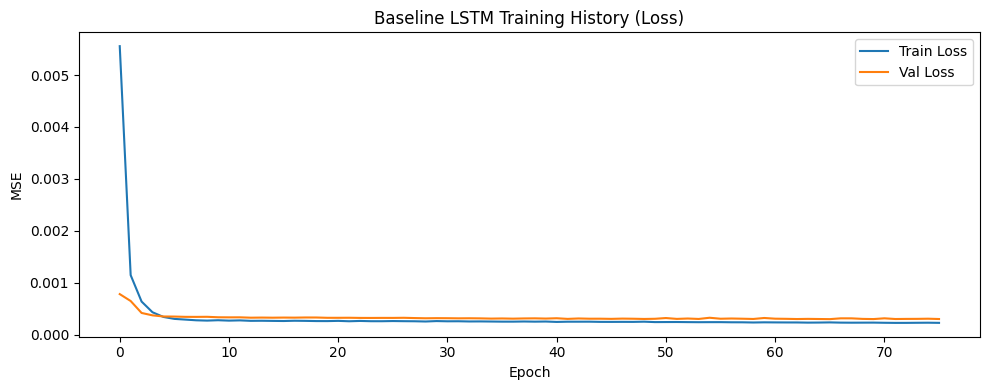

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(history_base.history["loss"], label="Train Loss")
plt.plot(history_base.history["val_loss"], label="Val Loss")
plt.title("Baseline LSTM Training History (Loss)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()


### Predict on test set and compute metrics

In [27]:
# Predict
y_pred_base_lstm = model_base.predict(X_test_base_seq).ravel()

# Metrics
mse_base_lstm  = mean_squared_error(y_test_base_seq, y_pred_base_lstm)
rmse_base_lstm = np.sqrt(mse_base_lstm)
mae_base_lstm  = mean_absolute_error(y_test_base_seq, y_pred_base_lstm)
r2_base_lstm   = r2_score(y_test_base_seq, y_pred_base_lstm)
dir_acc_base_lstm = directional_accuracy(y_test_base_seq, y_pred_base_lstm)

print("=== Baseline LSTM (Market-only) ===")
print(f"MSE : {mse_base_lstm:.6f}")
print(f"RMSE: {rmse_base_lstm:.6f}")
print(f"MAE : {mae_base_lstm:.6f}")
print(f"R²  : {r2_base_lstm:.4f}")
print(f"Directional Accuracy: {dir_acc_base_lstm:.4f}")


162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
=== Baseline LSTM (Market-only) ===
MSE : 0.000220
RMSE: 0.014816
MAE : 0.009792
R²  : -0.0434
Directional Accuracy: 0.4576


### Build DataFrame for plots (align by row_id)

In [28]:
# Build DF with predictions and row_id
lstm_base_df = pd.DataFrame({
    "row_id": row_ids_test_base,
    "target_ret_next": y_test_base_seq,
    "pred_lstm_base": y_pred_base_lstm,
})

# Attach date & ticker for plotting
plot_base_lstm = lstm_base_df.merge(
    features_model[["row_id", "date", "ticker"]],
    on="row_id",
    how="left"
)

plot_base_lstm["date"] = pd.to_datetime(plot_base_lstm["date"])
plot_base_lstm = plot_base_lstm.sort_values("date")

plot_base_lstm.head()


,row_id,target_ret_next,pred_lstm_base,date,ticker
0,ABB|2023-02-14,0.020572,-0.000296,2023-02-14,ABB
2350,NESTLE|2023-02-14,-0.005391,-0.000296,2023-02-14,NESTLE
3290,SWISS LIFE|2023-02-14,0.005831,-0.000296,2023-02-14,SWISS LIFE
1880,LONZA|2023-02-14,0.010242,-0.000296,2023-02-14,LONZA
3760,SWISSCOM|2023-02-14,0.002809,-0.000296,2023-02-14,SWISSCOM


### Baseline LSTM plots

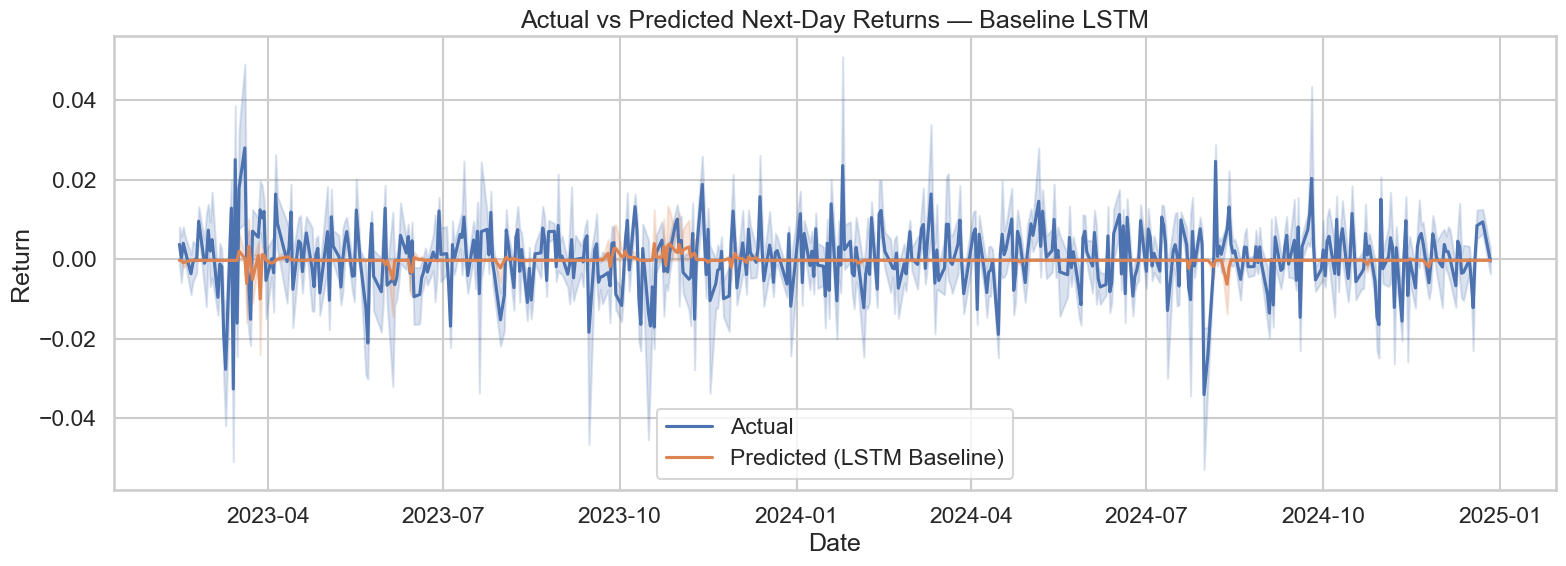

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="talk")

# 1) Actual vs Predicted over time
plt.figure(figsize=(16,6))
sns.lineplot(x="date", y="target_ret_next", data=plot_base_lstm, label="Actual")
sns.lineplot(x="date", y="pred_lstm_base", data=plot_base_lstm, label="Predicted (LSTM Baseline)")
plt.title("Actual vs Predicted Next-Day Returns — Baseline LSTM")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

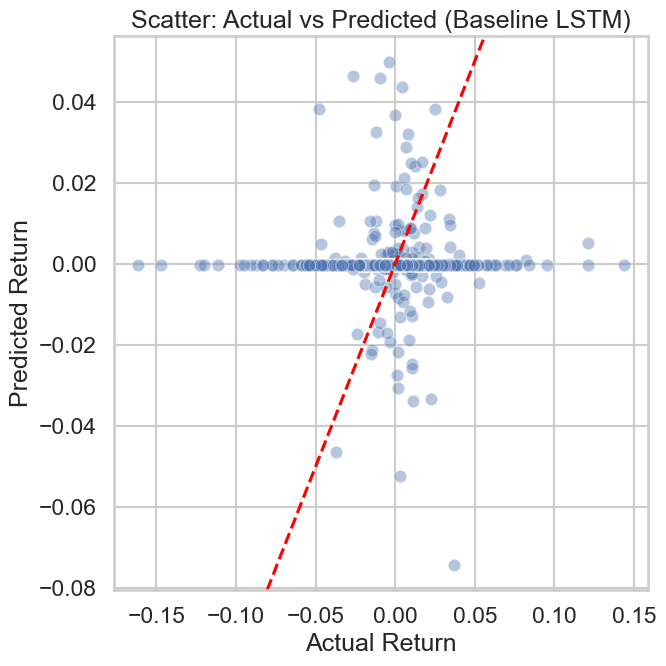

In [30]:
# 2) Scatter: Actual vs Predicted
plt.figure(figsize=(7,7))
sns.scatterplot(
    x=plot_base_lstm["target_ret_next"],
    y=plot_base_lstm["pred_lstm_base"],
    alpha=0.4
)
plt.axline((0,0), slope=1, color="red", linestyle="--")
plt.title("Scatter: Actual vs Predicted (Baseline LSTM)")
plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.tight_layout()
plt.show()

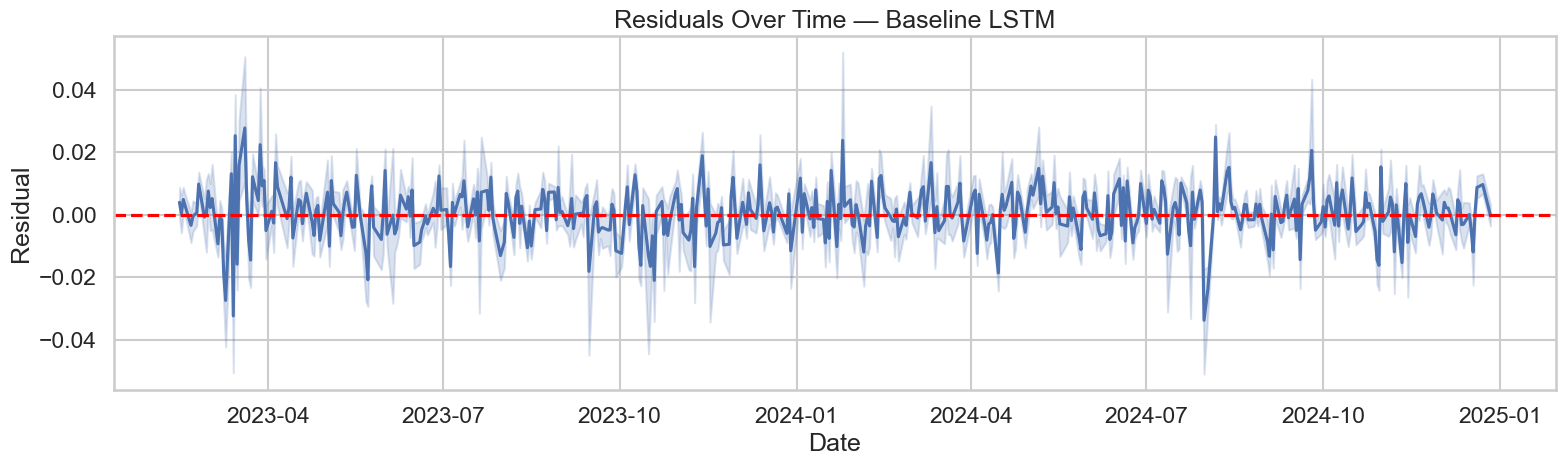

In [31]:
# 3) Residuals over time
plot_base_lstm["residual_lstm_base"] = (
    plot_base_lstm["target_ret_next"] - plot_base_lstm["pred_lstm_base"]
)

plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="residual_lstm_base", data=plot_base_lstm)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals Over Time — Baseline LSTM")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

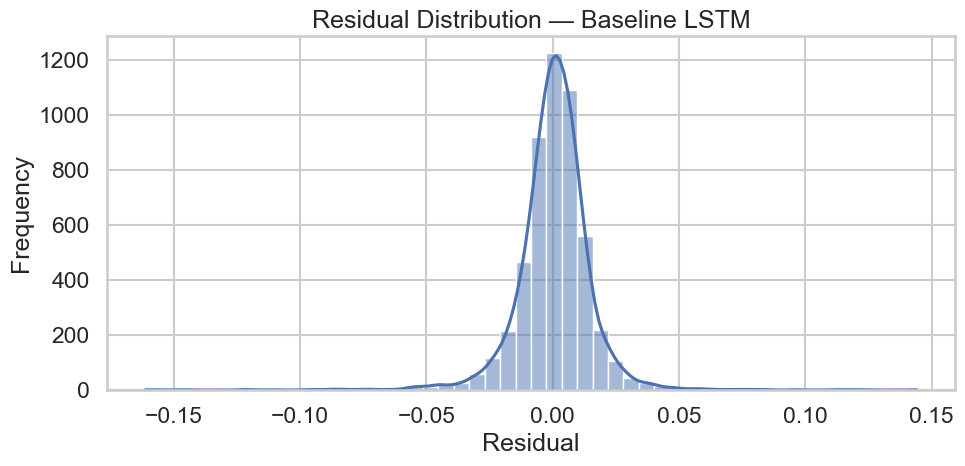

In [32]:
# 4) Residual distribution
plt.figure(figsize=(10,5))
sns.histplot(plot_base_lstm["residual_lstm_base"], kde=True, bins=50)
plt.title("Residual Distribution — Baseline LSTM")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

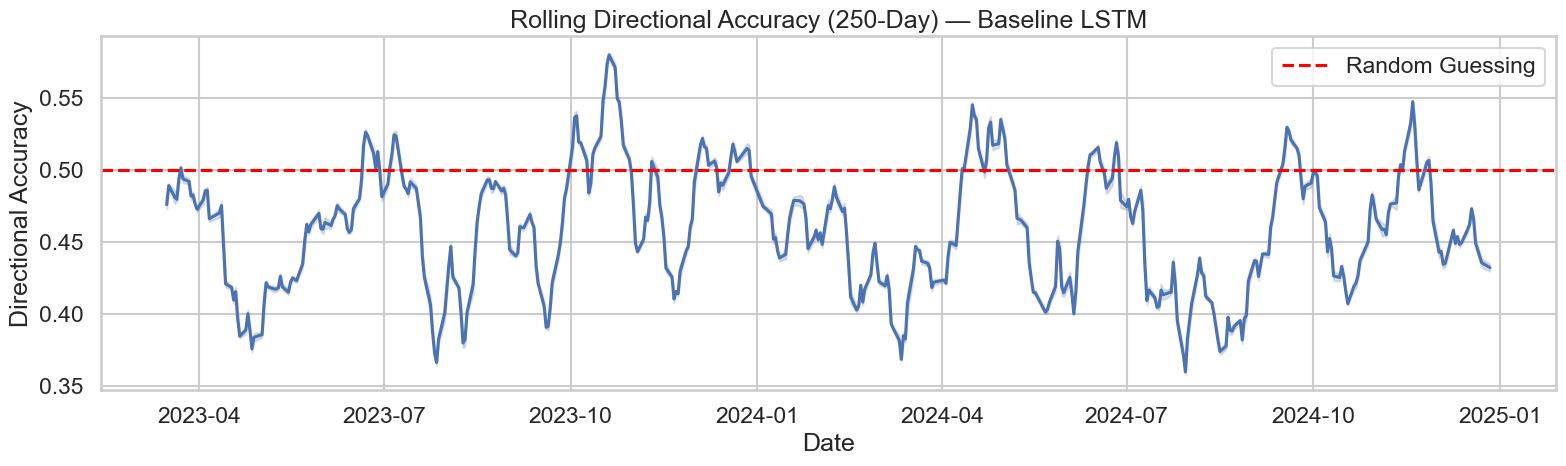

In [33]:
# 5) Rolling directional accuracy (250 days)
plot_base_lstm["correct_dir_lstm_base"] = (
    np.sign(plot_base_lstm["target_ret_next"])
    == np.sign(plot_base_lstm["pred_lstm_base"])
).astype(int)

plot_base_lstm["rolling_dir_acc_lstm_base"] = (
    plot_base_lstm["correct_dir_lstm_base"].rolling(250).mean()
)

plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="rolling_dir_acc_lstm_base", data=plot_base_lstm)
plt.axhline(0.5, color="red", linestyle="--", label="Random Guessing")
plt.title("Rolling Directional Accuracy (250-Day) — Baseline LSTM")
plt.xlabel("Date")
plt.ylabel("Directional Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Multimodal LSTM (Market + Sentiment)

### Train/validation split on multimodal sequences

In [34]:
# Keep same logic: last 20% of train as validation
n_train_mm = X_train_mm_seq.shape[0]
val_frac = 0.2
split_idx_mm = int((1 - val_frac) * n_train_mm)

X_train_mm_seq_train = X_train_mm_seq[:split_idx_mm]
y_train_mm_seq_train = y_train_mm_seq[:split_idx_mm]

X_val_mm_seq = X_train_mm_seq[split_idx_mm:]
y_val_mm_seq = y_train_mm_seq[split_idx_mm:]

print("Multimodal Train seq shape:", X_train_mm_seq_train.shape)
print("Multimodal Val seq shape  :", X_val_mm_seq.shape)
print("Multimodal Test seq shape :", X_test_mm_seq.shape)


Multimodal Train seq shape: (10243, 30, 17)
Multimodal Val seq shape  : (2561, 30, 17)
Multimodal Test seq shape : (5170, 30, 17)


### Define & train the Multimodal LSTM model

In [35]:
n_features_mm = X_train_mm_seq.shape[2]

model_mm = Sequential([
    LSTM(64, return_sequences=False, input_shape=(SEQ_LEN, n_features_mm)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)  # regression output
])

model_mm.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stopping_mm = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_mm = model_mm.fit(
    X_train_mm_seq_train, y_train_mm_seq_train,
    validation_data=(X_val_mm_seq, y_val_mm_seq),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping_mm],
    verbose=1
)


Epoch 1/100


c:\Users\mkcak\anaconda3\envs\financetech\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0042 - mae: 0.0463 - val_loss: 8.3745e-04 - val_mae: 0.0210
Epoch 2/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 9.9257e-04 - mae: 0.0236 - val_loss: 5.5869e-04 - val_mae: 0.0177
Epoch 3/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 6.1411e-04 - mae: 0.0183 - val_loss: 4.0151e-04 - val_mae: 0.0143
Epoch 4/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 4.2843e-04 - mae: 0.0150 - val_loss: 3.9998e-04 - val_mae: 0.0143
Epoch 5/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 3.6042e-04 - mae: 0.0138 - val_loss: 3.6169e-04 - val_mae: 0.0134
Epoch 6/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 3.3020e-04 - mae: 0.0130 - val_loss: 3.4951e-04 - val_mae: 0.0132
Epoch 7/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 3.1178e-04 - mae: 0.0125 - val_loss: 3.4970e-04 - val_mae: 0.0131
Epoch 8/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 2.9930e-04 - mae: 0.0122 - val_loss: 3.4325e-04 - val_mae:

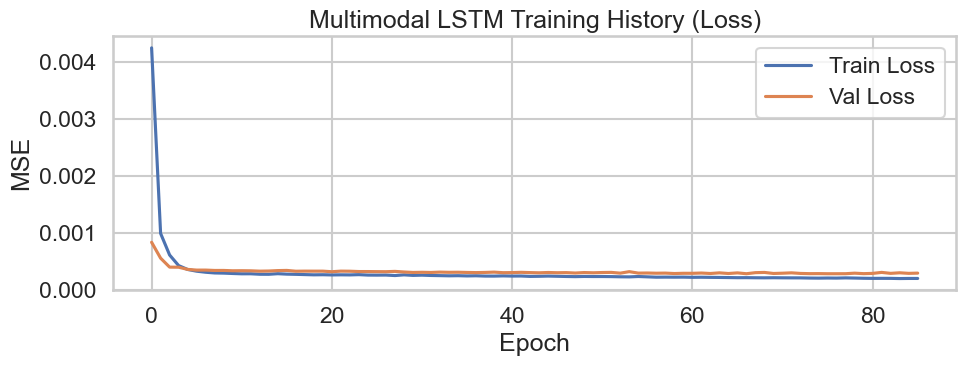

In [36]:
plt.figure(figsize=(10,4))
plt.plot(history_mm.history["loss"], label="Train Loss")
plt.plot(history_mm.history["val_loss"], label="Val Loss")
plt.title("Multimodal LSTM Training History (Loss)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()


### Predict on test set & compute metrics

In [37]:
# Predict
y_pred_mm_lstm = model_mm.predict(X_test_mm_seq).ravel()

# Metrics
mse_mm_lstm  = mean_squared_error(y_test_mm_seq, y_pred_mm_lstm)
rmse_mm_lstm = np.sqrt(mse_mm_lstm)
mae_mm_lstm  = mean_absolute_error(y_test_mm_seq, y_pred_mm_lstm)
r2_mm_lstm   = r2_score(y_test_mm_seq, y_pred_mm_lstm)
dir_acc_mm_lstm = directional_accuracy(y_test_mm_seq, y_pred_mm_lstm)

print("=== Multimodal LSTM (Market + Sentiment) ===")
print(f"MSE : {mse_mm_lstm:.6f}")
print(f"RMSE: {rmse_mm_lstm:.6f}")
print(f"MAE : {mae_mm_lstm:.6f}")
print(f"R²  : {r2_mm_lstm:.4f}")
print(f"Directional Accuracy: {dir_acc_mm_lstm:.4f}")


162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
=== Multimodal LSTM (Market + Sentiment) ===
MSE : 0.000218
RMSE: 0.014777
MAE : 0.009849
R²  : -0.0379
Directional Accuracy: 0.5178


### Build DataFrame for plots (align by row_id)

In [38]:
lstm_mm_df = pd.DataFrame({
    "row_id": row_ids_test_mm,
    "target_ret_next": y_test_mm_seq,
    "pred_lstm_mm": y_pred_mm_lstm,
})

plot_mm_lstm = lstm_mm_df.merge(
    features_model[["row_id", "date", "ticker"]],
    on="row_id",
    how="left"
)

plot_mm_lstm["date"] = pd.to_datetime(plot_mm_lstm["date"])
plot_mm_lstm = plot_mm_lstm.sort_values("date")

plot_mm_lstm.head()


,row_id,target_ret_next,pred_lstm_mm,date,ticker
0,ABB|2023-02-14,0.020572,0.000836,2023-02-14,ABB
2350,NESTLE|2023-02-14,-0.005391,0.000836,2023-02-14,NESTLE
3290,SWISS LIFE|2023-02-14,0.005831,0.000836,2023-02-14,SWISS LIFE
1880,LONZA|2023-02-14,0.010242,0.000836,2023-02-14,LONZA
3760,SWISSCOM|2023-02-14,0.002809,0.000836,2023-02-14,SWISSCOM


### Multimodal LSTM plots

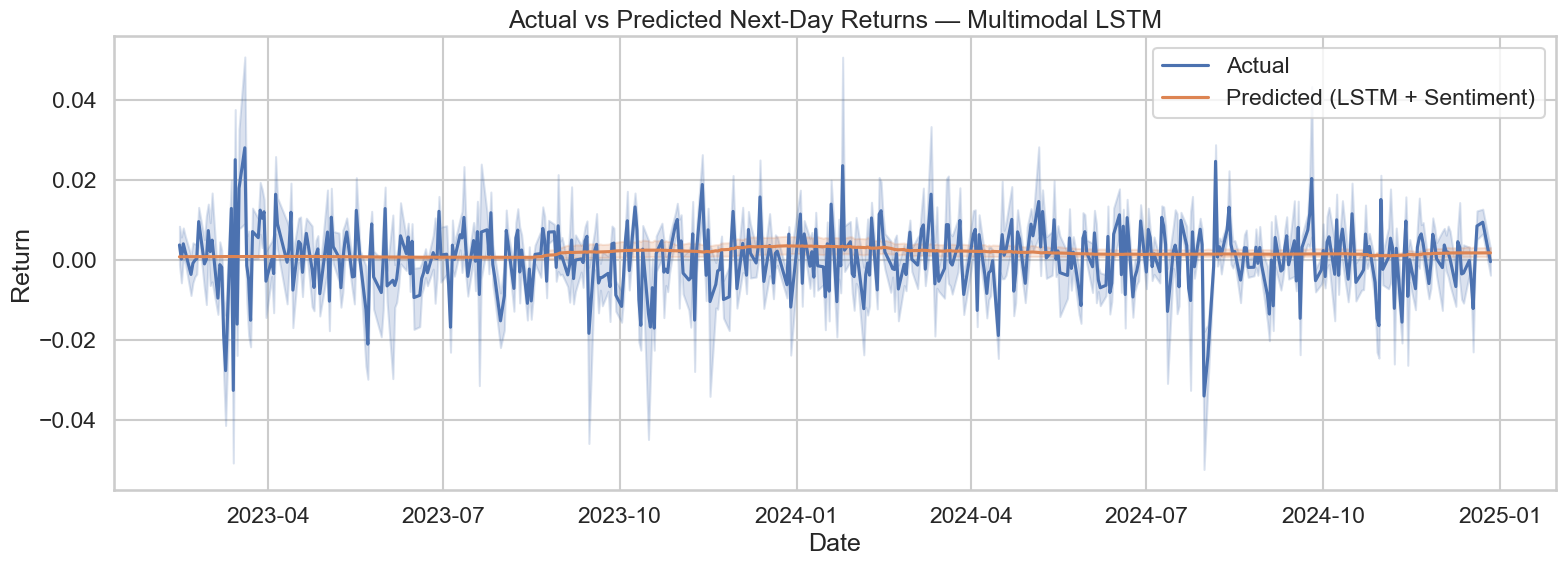

In [39]:
sns.set(style="whitegrid", context="talk")

# 1) Actual vs Predicted over time
plt.figure(figsize=(16,6))
sns.lineplot(x="date", y="target_ret_next", data=plot_mm_lstm, label="Actual")
sns.lineplot(x="date", y="pred_lstm_mm", data=plot_mm_lstm, label="Predicted (LSTM + Sentiment)")
plt.title("Actual vs Predicted Next-Day Returns — Multimodal LSTM")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

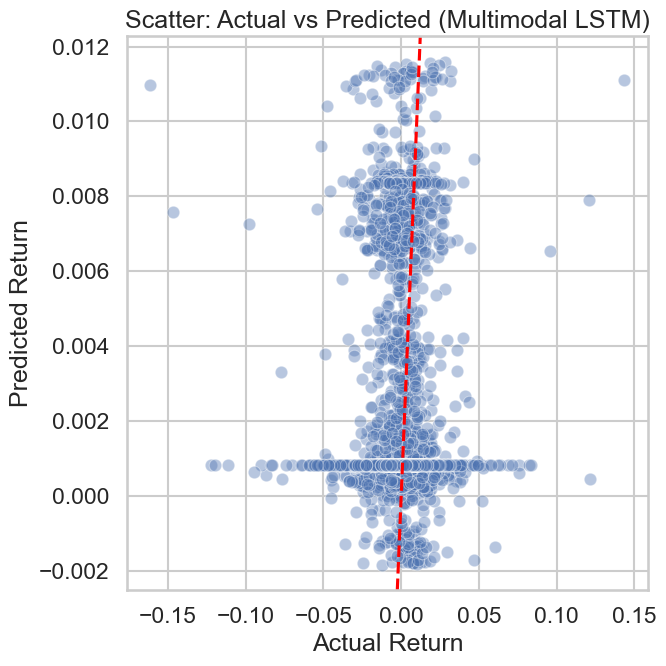

In [40]:
# 2) Scatter: Actual vs Predicted
plt.figure(figsize=(7,7))
sns.scatterplot(
    x=plot_mm_lstm["target_ret_next"],
    y=plot_mm_lstm["pred_lstm_mm"],
    alpha=0.4
)
plt.axline((0,0), slope=1, color="red", linestyle="--")
plt.title("Scatter: Actual vs Predicted (Multimodal LSTM)")
plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.tight_layout()
plt.show()

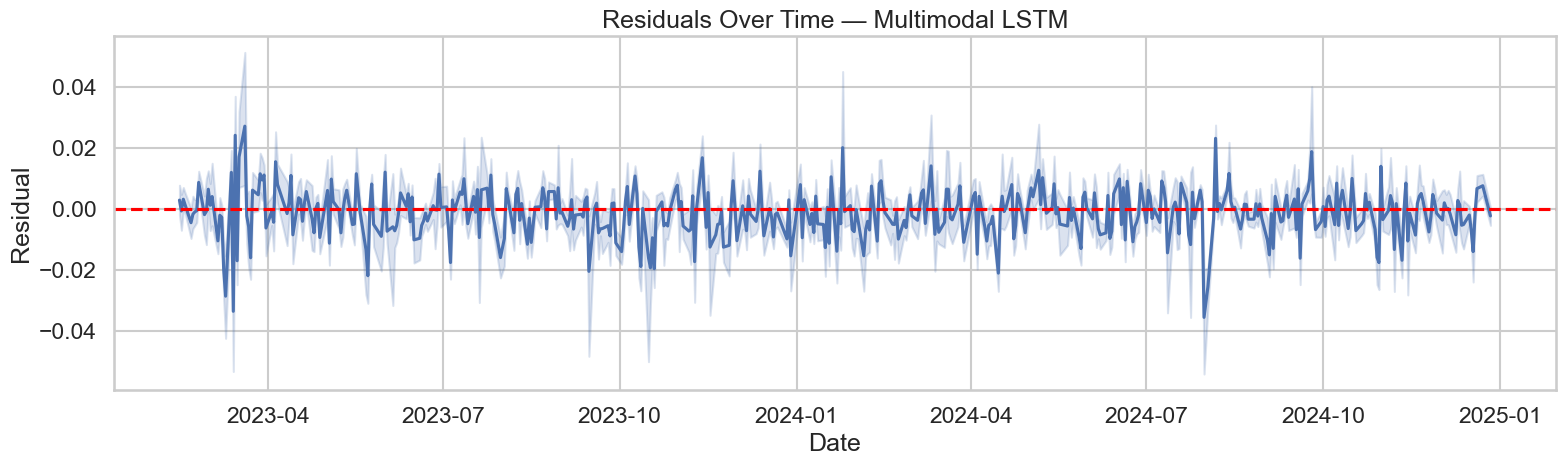

In [41]:
# 3) Residuals over time
plot_mm_lstm["residual_lstm_mm"] = (
    plot_mm_lstm["target_ret_next"] - plot_mm_lstm["pred_lstm_mm"]
)

plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="residual_lstm_mm", data=plot_mm_lstm)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals Over Time — Multimodal LSTM")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

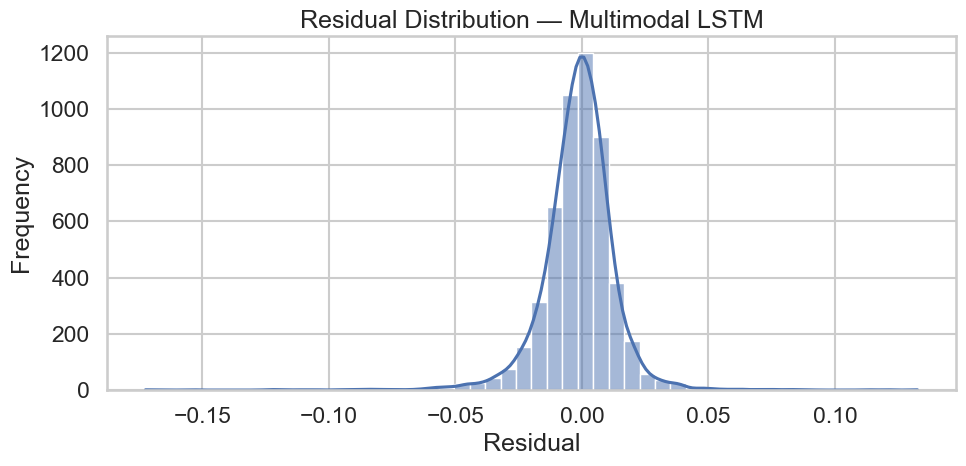

In [42]:
# 4) Residual distribution
plt.figure(figsize=(10,5))
sns.histplot(plot_mm_lstm["residual_lstm_mm"], kde=True, bins=50)
plt.title("Residual Distribution — Multimodal LSTM")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

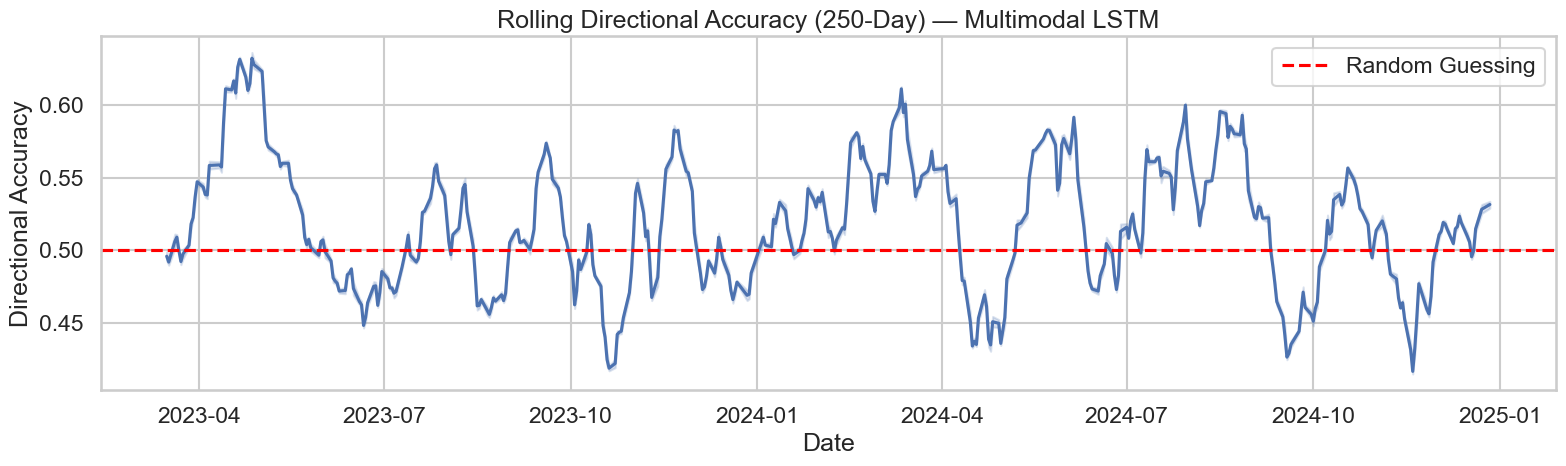

In [43]:
# 5) Rolling directional accuracy (250 days)
plot_mm_lstm["correct_dir_lstm_mm"] = (
    np.sign(plot_mm_lstm["target_ret_next"])
    == np.sign(plot_mm_lstm["pred_lstm_mm"])
).astype(int)

plot_mm_lstm["rolling_dir_acc_lstm_mm"] = (
    plot_mm_lstm["correct_dir_lstm_mm"].rolling(250).mean()
)

plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="rolling_dir_acc_lstm_mm", data=plot_mm_lstm)
plt.axhline(0.5, color="red", linestyle="--", label="Random Guessing")
plt.title("Rolling Directional Accuracy (250-Day) — Multimodal LSTM")
plt.xlabel("Date")
plt.ylabel("Directional Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### Quick comparison table

In [44]:
summary_rows = [

    {
        "Model": "LSTM Baseline",
        "RMSE": rmse_base_lstm,
        "MAE": mae_base_lstm,
        "R2": r2_base_lstm,
        "DirAcc": dir_acc_base_lstm,
    },
    {
        "Model": "LSTM + Sentiment",
        "RMSE": rmse_mm_lstm,
        "MAE": mae_mm_lstm,
        "R2": r2_mm_lstm,
        "DirAcc": dir_acc_mm_lstm,
    },
]

results_summary = pd.DataFrame(summary_rows)
results_summary


,Model,RMSE,MAE,R2,DirAcc
0,LSTM Baseline,0.014816,0.009792,-0.043408,0.457640
1,LSTM + Sentiment,0.014777,0.009849,-0.037868,0.517795


## Analysis

### Combine Baseline & Multimodal LSTM predictions

In [45]:
# Start from baseline LSTM test DF
cmp_lstm = plot_base_lstm[["row_id", "date", "ticker", "target_ret_next", "pred_lstm_base"]].copy()

# Add multimodal LSTM predictions (matched by row_id)
tmp_mm_lstm = plot_mm_lstm[["row_id", "pred_lstm_mm"]].copy()

cmp_lstm = cmp_lstm.merge(tmp_mm_lstm, on="row_id", how="inner")

cmp_lstm.head()


,row_id,date,ticker,target_ret_next,pred_lstm_base,pred_lstm_mm
0,ABB|2023-02-14,2023-02-14,ABB,0.020572,-0.000296,0.000836
1,NESTLE|2023-02-14,2023-02-14,NESTLE,-0.005391,-0.000296,0.000836
2,SWISS LIFE|2023-02-14,2023-02-14,SWISS LIFE,0.005831,-0.000296,0.000836
3,LONZA|2023-02-14,2023-02-14,LONZA,0.010242,-0.000296,0.000836
4,SWISSCOM|2023-02-14,2023-02-14,SWISSCOM,0.002809,-0.000296,0.000836


### Per-company (ticker-level) metrics for LSTM

In [46]:
from sklearn.metrics import mean_squared_error

company_metrics_lstm = (
    cmp_lstm.groupby("ticker")
            .apply(lambda df: pd.Series({
                "RMSE_lstm_base":  np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_lstm_base"])),
                "RMSE_lstm_mm":    np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_lstm_mm"])),
                "DirAcc_lstm_base": np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_lstm_base"])),
                "DirAcc_lstm_mm":   np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_lstm_mm"])),
            }))
            .reset_index()
)

company_metrics_lstm_sorted = company_metrics_lstm.sort_values("DirAcc_lstm_mm", ascending=False)
company_metrics_lstm_sorted


C:\Users\mkcak\AppData\Local\Temp\ipykernel_31936\1409806439.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,ticker,RMSE_lstm_base,RMSE_lstm_mm,DirAcc_lstm_base,DirAcc_lstm_mm
7,SWISS LIFE,0.011720,0.011615,0.412766,0.568085
0,ABB,0.013853,0.013644,0.429787,0.559574
2,HELVETIA,0.011677,0.011619,0.414894,0.544681
1,BKW ENERGIE,0.014365,0.014145,0.446809,0.538298
8,SWISSCOM,0.008136,0.008491,0.455319,0.512766
4,LONZA,0.021627,0.021035,0.495745,0.510638
10,VONTOBEL,0.011944,0.011909,0.400000,0.508511
9,UBS,0.018478,0.017842,0.446809,0.504255
3,JULIUS BAER,0.017779,0.017786,0.500000,0.500000
6,SWATCH,0.017700,0.018848,0.519149,0.474468


### Cap-level metrics (Small / Mid / Large Cap) for LSTM

In [47]:
# Attach cap info via row_id
cmp_lstm_cap = cmp_lstm.merge(
    features_model[["row_id", "cap"]],
    on="row_id",
    how="left"
)

cap_metrics_lstm = (
    cmp_lstm_cap.groupby("cap")
                .apply(lambda df: pd.Series({
                    "RMSE_lstm_base":  np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_lstm_base"])),
                    "RMSE_lstm_mm":    np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_lstm_mm"])),
                    "DirAcc_lstm_base": np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_lstm_base"])),
                    "DirAcc_lstm_mm":   np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_lstm_mm"])),
                }))
                .reset_index()
)

cap_metrics_lstm

C:\Users\mkcak\AppData\Local\Temp\ipykernel_31936\3573356970.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,cap,RMSE_lstm_base,RMSE_lstm_mm,DirAcc_lstm_base,DirAcc_lstm_mm
0,Large Cap,0.015057,0.015020,0.456383,0.534043
1,Mid Cap,0.013853,0.013644,0.429787,0.559574
2,Small Cap,0.014872,0.014852,0.461436,0.508511


### Sector-level metrics for LSTM

In [48]:
# Attach sector info
cmp_lstm_sector = cmp_lstm.merge(
    features_model[["row_id", "sector"]],
    on="row_id",
    how="left"
)

sector_metrics_lstm = (
    cmp_lstm_sector.groupby("sector")
                   .apply(lambda df: pd.Series({
                       "RMSE_lstm_base":  np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_lstm_base"])),
                       "RMSE_lstm_mm":    np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_lstm_mm"])),
                       "DirAcc_lstm_base": np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_lstm_base"])),
                       "DirAcc_lstm_mm":   np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_lstm_mm"])),
                   }))
                   .reset_index()
)

sector_metrics_lstm.sort_values("DirAcc_lstm_mm", ascending=False)


C:\Users\mkcak\AppData\Local\Temp\ipykernel_31936\1200789333.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,sector,RMSE_lstm_base,RMSE_lstm_mm,DirAcc_lstm_base,DirAcc_lstm_mm
4,Insurance,0.011698,0.011617,0.413830,0.556383
5,Real Estate - Energy - Industrials,0.014111,0.013897,0.438298,0.548936
6,Technology,0.008136,0.008491,0.455319,0.512766
3,Health Care,0.021627,0.021035,0.495745,0.510638
0,Banking,0.016332,0.016088,0.448936,0.504255
2,Consumer Staples,0.009766,0.009975,0.512766,0.474468
1,Consumer Discretionary,0.017700,0.018848,0.519149,0.474468


## Save Models / Metrics / Results

In [49]:
# === SAVE: LSTM models ===
model_base.save(LSTM_MODELS_DIR / "lstm_base_market_only.keras")
model_mm.save(LSTM_MODELS_DIR / "lstm_mm_multimodal.keras")

print("Saved LSTM models:")
print(" - lstm_base_market_only.keras")
print(" - lstm_mm_multimodal.keras")

# === SAVE: training histories ===
hist_base_df = pd.DataFrame(history_base.history)
hist_mm_df   = pd.DataFrame(history_mm.history)

hist_base_df.to_csv(LSTM_RESULTS_DIR / "history_lstm_base.csv", index=False)
hist_mm_df.to_csv(LSTM_RESULTS_DIR / "history_lstm_mm.csv", index=False)

print("Saved LSTM training histories:")
print(" - history_lstm_base.csv")
print(" - history_lstm_mm.csv")



Saved LSTM models:
 - lstm_base_market_only.keras
 - lstm_mm_multimodal.keras
Saved LSTM training histories:
 - history_lstm_base.csv
 - history_lstm_mm.csv


In [50]:
# === SAVE: overall LSTM metrics ===
results_summary.to_csv(LSTM_RESULTS_DIR / "overall_metrics_lstm.csv", index=False)
print("Saved LSTM overall metrics -> overall_metrics_lstm.csv")


Saved LSTM overall metrics -> overall_metrics_lstm.csv


In [51]:
# === Attach cap & sector info for full cmp table ===
cmp_lstm_full = cmp_lstm.merge(
    features_model[["row_id", "cap", "sector"]],
    on="row_id",
    how="left"
)

# === SAVE: detailed LSTM results ===
cmp_lstm.to_parquet(LSTM_RESULTS_DIR / "cmp_lstm_base_vs_mm.parquet")
cmp_lstm_full.to_parquet(LSTM_RESULTS_DIR / "cmp_lstm_base_vs_mm_full.parquet")

company_metrics_lstm.to_csv(LSTM_RESULTS_DIR / "company_metrics_lstm.csv", index=False)
cap_metrics_lstm.to_csv(LSTM_RESULTS_DIR / "cap_metrics_lstm.csv", index=False)
sector_metrics_lstm.to_csv(LSTM_RESULTS_DIR / "sector_metrics_lstm.csv", index=False)

print("Saved LSTM detailed metrics and comparisons:")
print(" - cmp_lstm_base_vs_mm.parquet")
print(" - cmp_lstm_base_vs_mm_full.parquet")
print(" - company_metrics_lstm.csv")
print(" - cap_metrics_lstm.csv")
print(" - sector_metrics_lstm.csv")


Saved LSTM detailed metrics and comparisons:
 - cmp_lstm_base_vs_mm.parquet
 - cmp_lstm_base_vs_mm_full.parquet
 - company_metrics_lstm.csv
 - cap_metrics_lstm.csv
 - sector_metrics_lstm.csv
